# Pacman RL — Final Notebook (Q-learning, SARSA, DQN, MCTS)

Contenu : rendu de l'env (10×10, 2 fantômes), entraînement + superposition des récompenses, comparaison du win-rate, sweeps de paramètres, tests de robustesse et de dynamisme.

In [1]:
import os
import numpy as np
from src.env import PacmanGridEnv, make_grid
from src.training import train_all, optimal_path_render, eval_policy, sweep_rewards_q_sarsa, sweep_rewards_dqn
from src.utils import plot_training_curves, plot_overlay_rewards, show_metrics
from src.policies import EpsilonGreedySchedule
from src.algos.q_learning import train_q_learning, greedy_action_from_q
from src.algos.sarsa import train_sarsa
from src.algos.dqn import train_dqn
from src.algos.mcts import plan_action
from pathlib import Path

out_dir = 'outputs/images'; Path(out_dir).mkdir(parents=True, exist_ok=True)

## 1) Environnement 10×10 (2 fantômes) + rendu

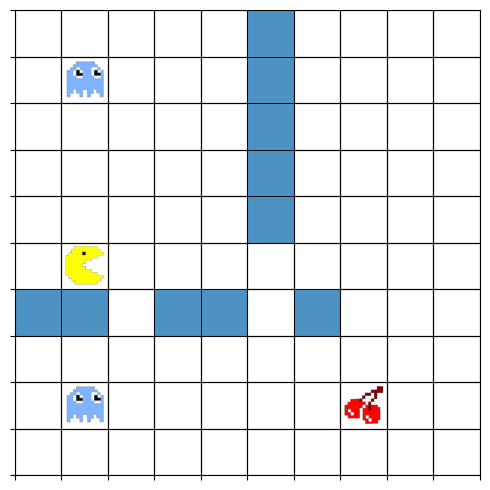

In [2]:
grid, dot_pos, ghost_starts, pacman_start = make_grid()
nb_ghosts = len(ghost_starts)
env = PacmanGridEnv(grid=grid, dot_pos=dot_pos, ghost_starts=ghost_starts, pacman_start=pacman_start,
                    noise_prob=0.0, random_start=False, move_prob_ghost=0.0, n_ghosts=nb_ghosts, seed=0, assets_dir='assets')
env.render(borders=True, save_path=f"{out_dir}/env_initial_10x10_2ghosts.png")

In [3]:
max_steps = grid.size
max_steps

100

## 2) Entraînement de toutes les méthodes de Q-learning

100%|██████████| 1500/1500 [00:06<00:00, 231.83it/s]


Q-learning: training time = 6.47s | evaluation time = 0.00s


100%|██████████| 1500/1500 [00:05<00:00, 284.14it/s]


SARSA: training time = 5.28s | evaluation time = 0.00s


100%|██████████| 1500/1500 [07:33<00:00,  3.31it/s]


DQN: training time = 453.66s | evaluation time = 0.00s


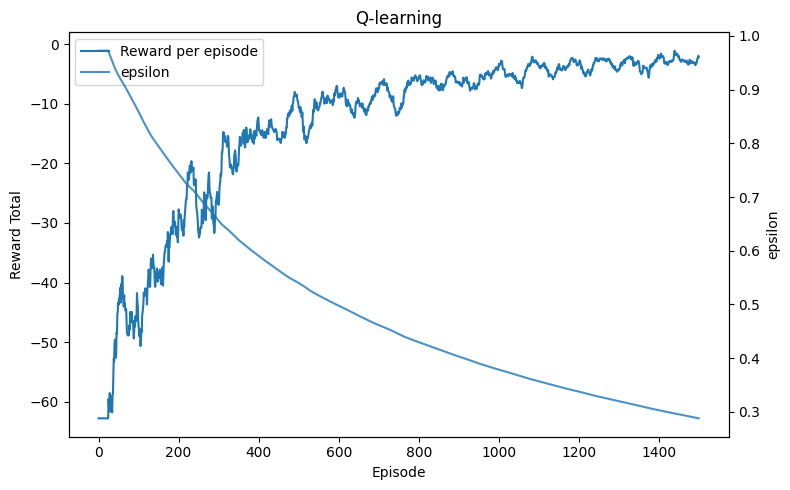

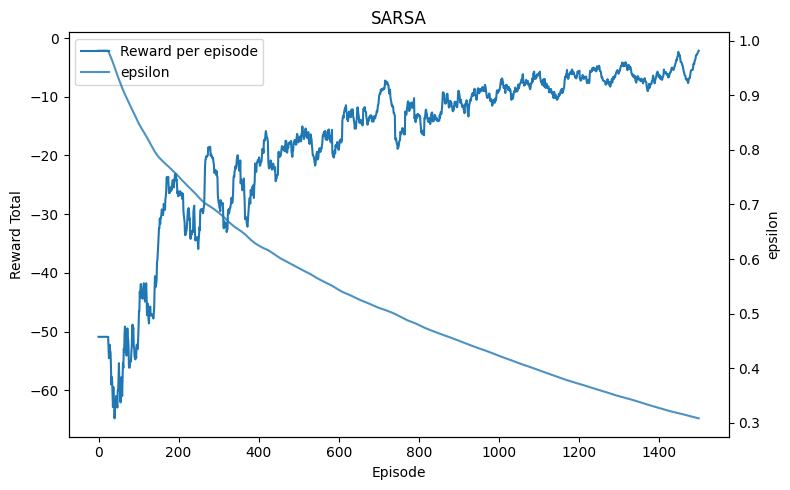

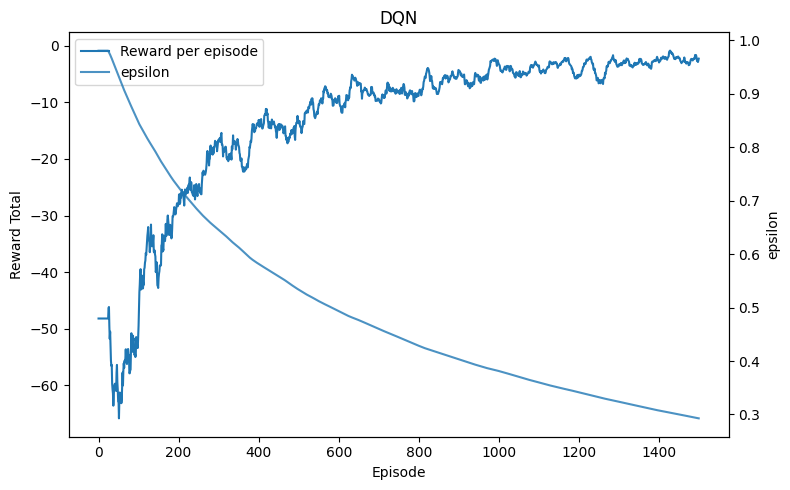


=== Method comparison ===
Q-learning: Winrate: 100.0000% | Mean reward: 2.00
SARSA: Winrate: 100.0000% | Mean reward: 2.00
DQN: Winrate: 100.0000% | Mean reward: 2.00


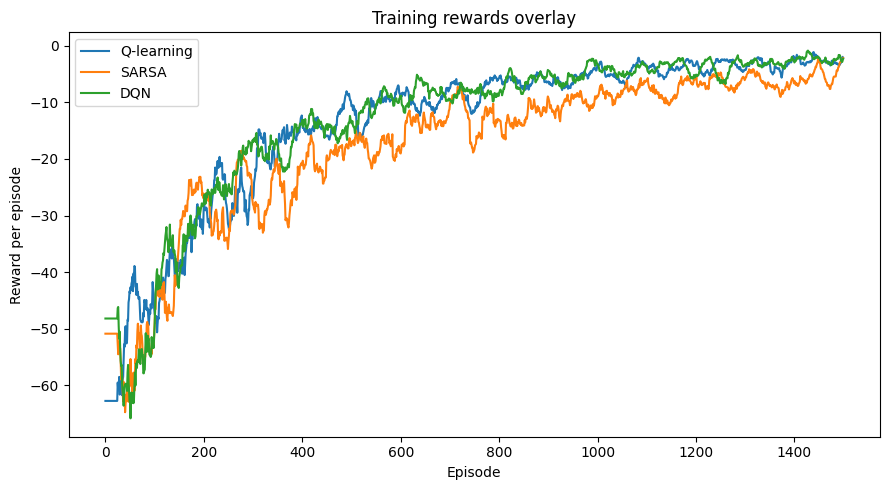

In [10]:
results = train_all(env, out_dir=out_dir, episodes=1500, max_steps=max_steps, gamma=0.99, eps_mode='exp')


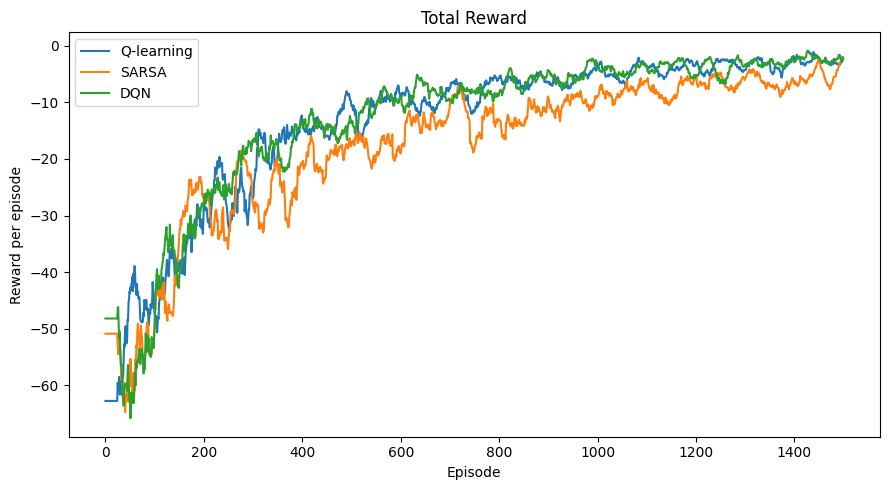

In [11]:
logs = {k: v[1] for k,v in results.items()}
plot_overlay_rewards(logs, title='Total Reward', out_path=f"{out_dir}/overlay_base.png")

Q-learning


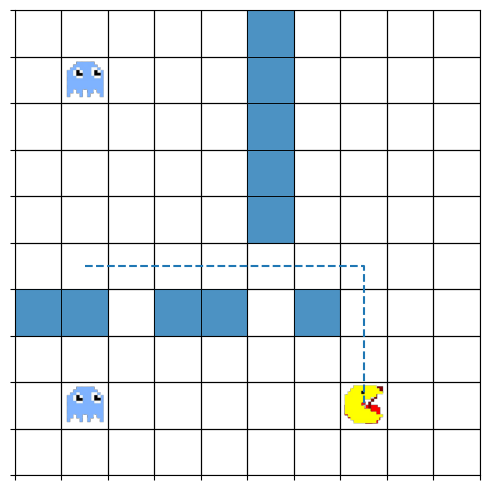

SARSA


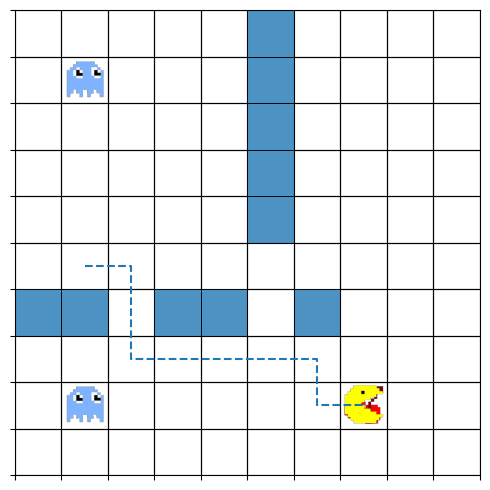

DQN


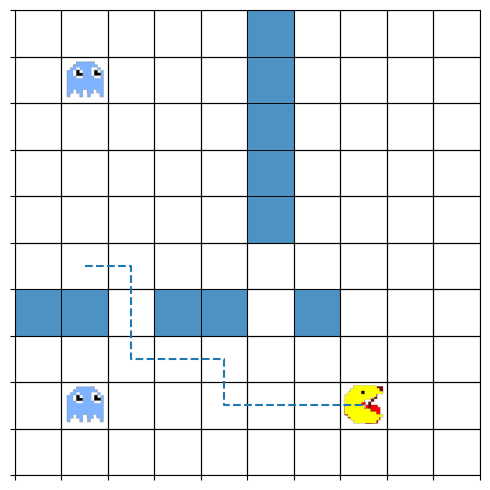

In [12]:
for name, (policy, log, metrics) in results.items():
    if policy is not None:
        print(name)
        optimal_path_render(env, policy, out_path=f"{out_dir}/optimal_path_found_by_{name}.png")

## 3) Monte Carlo Tree Search 

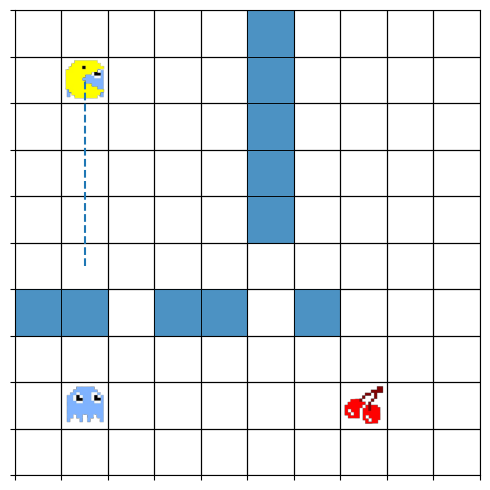

In [5]:
env.reset()
env.ghost_penalty = -10
env.dot_reward = 10
env.step_cost = -1

def mcts_policy(_obs): return plan_action(env, simulations=100, c=1, rollout_depth=20, gamma=0.99)

# metrics = eval_policy(env, mcts_policy, episodes=50)
# wr = metrics['win_rate'] * 100
# mr = metrics['mean_reward']
# print(f"Winrate: {wr:.4f}% | Mean reward: {mr:.2f}")
optimal_path_render(env, mcts_policy, out_path = "optimal_path_found_by_MCTS_1")

Winrate: 100.0% | Mean reward: -21.18


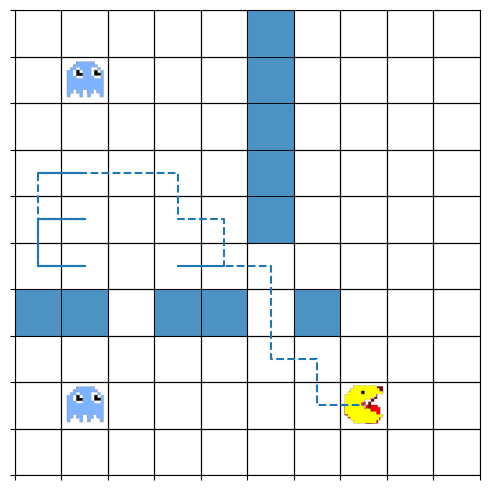

In [ ]:
env.reset()
env.ghost_penalty = -100
env.dot_reward = 10
env.step_cost = -1

def mcts_policy(_obs): return plan_action(env, simulations=100, c=1, rollout_depth=20, gamma=0.99)

metrics = eval_policy(env, mcts_policy, episodes=50, max_steps=200)
wr = metrics['win_rate'] * 100
mr = metrics['mean_reward']
print(f"Winrate: {wr}% | Mean reward: {mr}")
optimal_path_render(env, mcts_policy, out_path = "optimal_path_found_by_MCTS_2")

Winrate: 0.0000% | Mean reward: -146.60


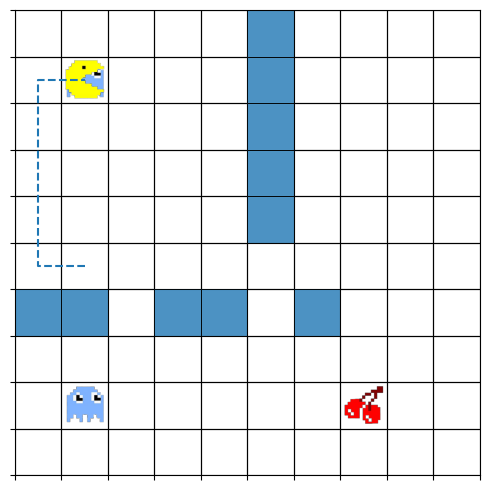

In [ ]:
env.reset()
env.ghost_penalty = -100
env.dot_reward = 10
env.step_cost = -10

def mcts_policy(_obs): return plan_action(env, simulations=100, c=1, rollout_depth=20, gamma=0.99)

metrics = eval_policy(env, mcts_policy, episodes=50)
wr = metrics['win_rate'] * 100
mr = metrics['mean_reward']
print(f"Winrate: {wr:.4f}% | Mean reward: {mr:.2f}")

optimal_path_render(env, mcts_policy, out_path = "optimal_path_found_by_MCTS_3")

Winrate: 100.0000% | Mean reward: -219.80


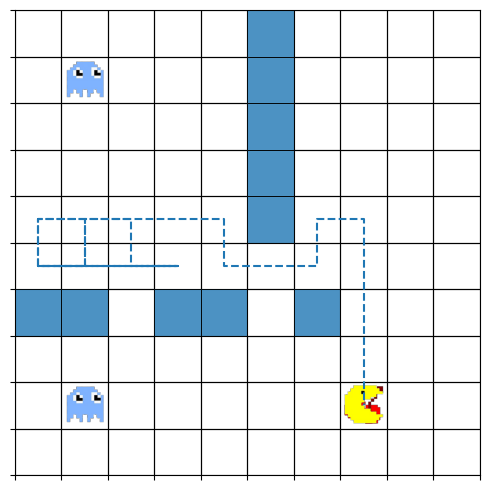

In [ ]:
env.reset()
env.ghost_penalty = -1000
env.dot_reward = 10
env.step_cost = -10

def mcts_policy(_obs): return plan_action(env, simulations=100, c=1, rollout_depth=20, gamma=0.99)

metrics = eval_policy(env, mcts_policy, episodes=50)
wr = metrics['win_rate'] * 100
mr = metrics['mean_reward']
print(f"Winrate: {wr:.4f}% | Mean reward: {mr:.2f}")
optimal_path_render(env, mcts_policy, out_path = "optimal_path_found_by_MCTS_4")

Winrate: 100.0000% | Mean reward: -183.80


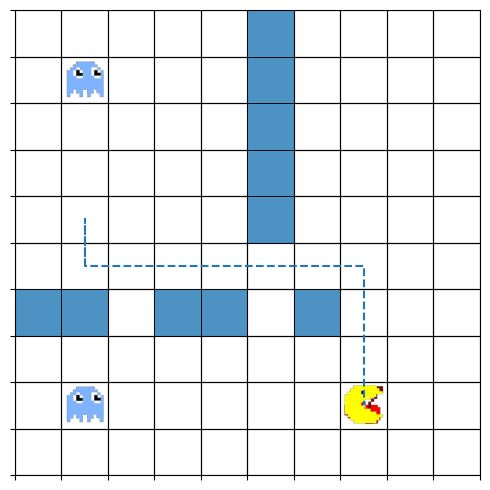

In [ ]:
env.reset()
env.ghost_penalty = -1000
env.dot_reward = 100
env.step_cost = -10

def mcts_policy(_obs): return plan_action(env, simulations=100, c=1, rollout_depth=20, gamma=0.99)

metrics = eval_policy(env, mcts_policy, episodes=50)
wr = metrics['win_rate'] * 100
mr = metrics['mean_reward']
print(f"Winrate: {wr:.4f}% | Mean reward: {mr:.2f}")

optimal_path_render(env, mcts_policy, out_path = "optimal_path_found_by_MCTS_5")


Winrate: 100.0000% | Mean reward: -183.80


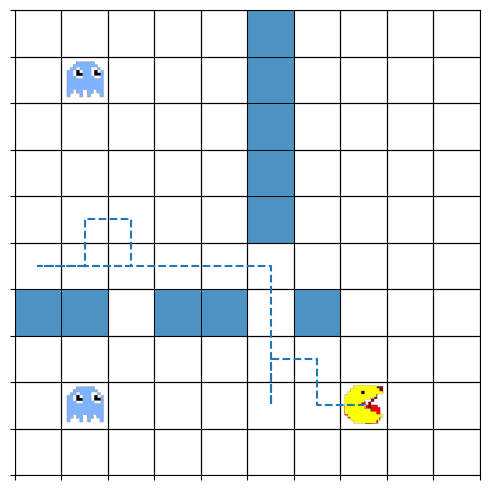

In [ ]:
env.reset()
env.ghost_penalty = -100
env.dot_reward = 100
env.step_cost = -10

def mcts_policy(_obs): return plan_action(env, simulations=100, c=1, rollout_depth=20, gamma=0.8)

mcts_metrics = eval_policy(env, mcts_policy, episodes=50)
wr = metrics['win_rate'] * 100
mr = metrics['mean_reward']
print(f"Winrate: {wr:.4f}% | Mean reward: {mr:.2f}")

optimal_path_render(env, mcts_policy, out_path = "optimal_path_found_by_MCTS_5")


## 4) Impact des hyperparamètres (pour les algos de Q-learning)

  0%|          | 0/600 [00:00<?, ?it/s]d:\Code\Projets Github\Q-PACMAN\src\algos\q_learning.py:36: RuntimeWarning: overflow encountered in scalar multiply
  Qsa[a] += alpha * (td_target - Qsa[a])
d:\Code\Projets Github\Q-PACMAN\src\algos\q_learning.py:36: RuntimeWarning: invalid value encountered in scalar add
  Qsa[a] += alpha * (td_target - Qsa[a])
d:\Code\Projets Github\Q-PACMAN\src\algos\q_learning.py:36: RuntimeWarning: invalid value encountered in scalar subtract
  Qsa[a] += alpha * (td_target - Qsa[a])
  4%|▎         | 22/600 [00:00<00:05, 102.56it/s]d:\Code\Projets Github\Q-PACMAN\src\algos\sarsa.py:30: RuntimeWarning: overflow encountered in scalar multiply
  Qsa[a] += alpha * (td_target - Qsa[a])
d:\Code\Projets Github\Q-PACMAN\src\algos\sarsa.py:30: RuntimeWarning: invalid value encountered in scalar add
  Qsa[a] += alpha * (td_target - Qsa[a])
d:\Code\Projets Github\Q-PACMAN\src\algos\sarsa.py:30: RuntimeWarning: invalid value encountered in scalar subtract
  Qsa[a] += alph

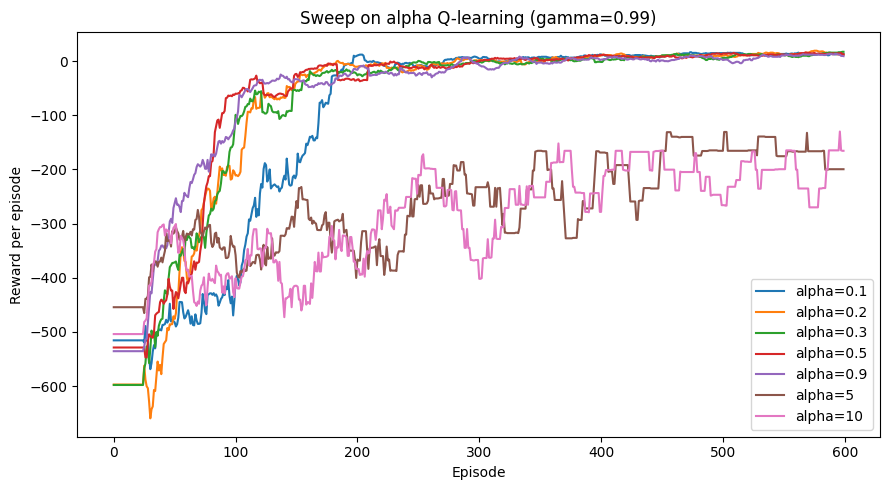

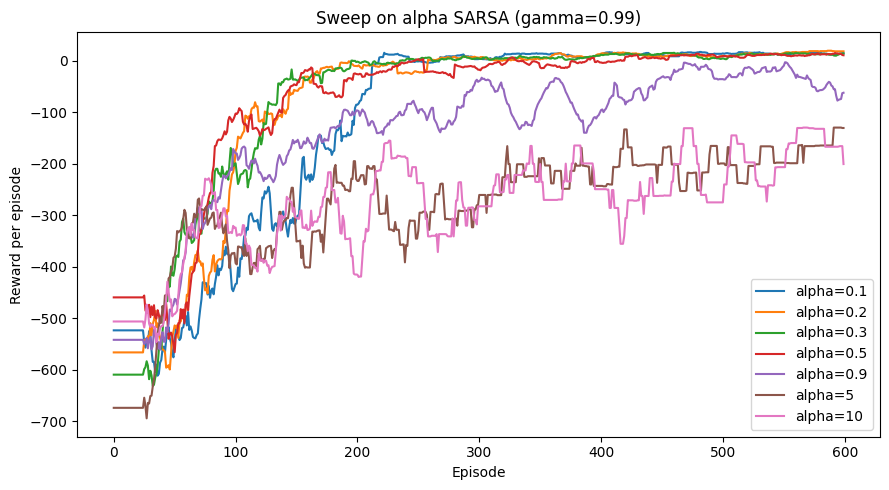

100%|██████████| 600/600 [00:01<00:00, 411.45it/s]


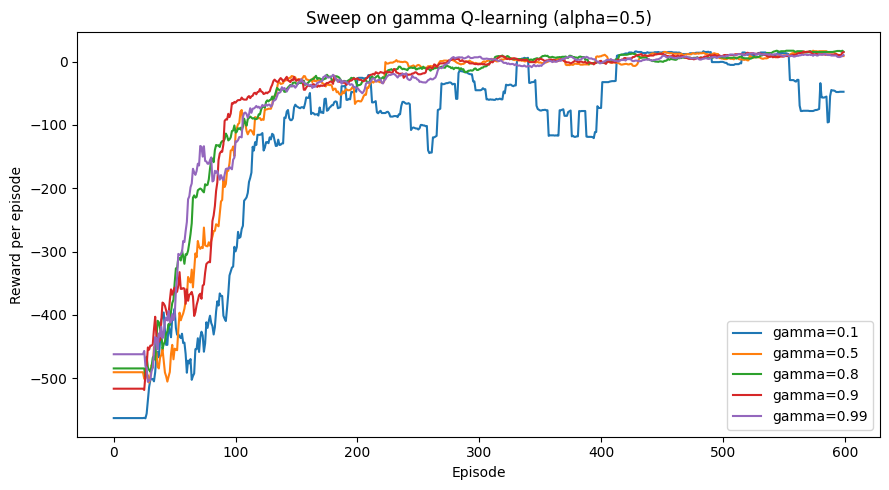

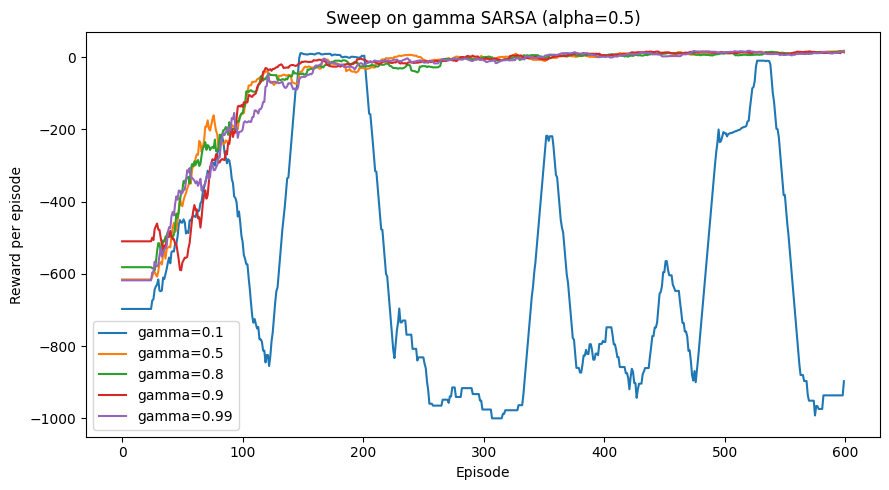

In [22]:
base_qs = {
    "eps_schedule": EpsilonGreedySchedule(start=1.0, end=0.05, decay_steps=10_000, mode="exp"),
    "alpha": 0.5,
    "gamma": 0.99
}

logs_q, logs_s = sweep_rewards_q_sarsa(
    env, param="alpha", values=[0.1, 0.2, 0.3, 0.5, 0.9, 5, 10],
    base=base_qs, episodes=600, max_steps=max_steps,
    title_prefix="Sweep on alpha",
    out_path="outputs/images/sweep_q_sarsa_alpha.png"
)

logs_q, logs_s = sweep_rewards_q_sarsa(
    env, param="gamma", values=[0.1, 0.5, 0.8, 0.9, 0.99, 0.99],
    base=base_qs, episodes=600, max_steps=max_steps,
    title_prefix="Sweep on gamma",
    out_path="outputs/images/sweep_q_sarsa_gamma.png"
)




100%|██████████| 600/600 [07:22<00:00,  1.35it/s]


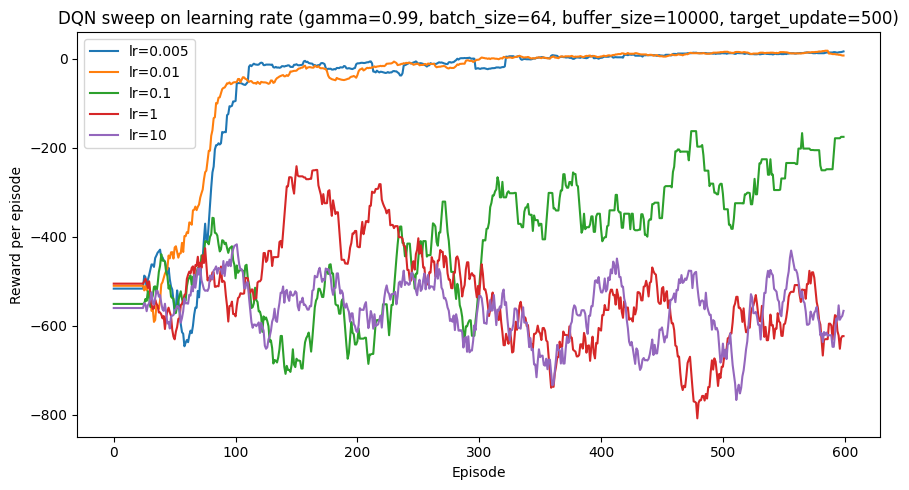

100%|██████████| 600/600 [02:06<00:00,  4.74it/s]


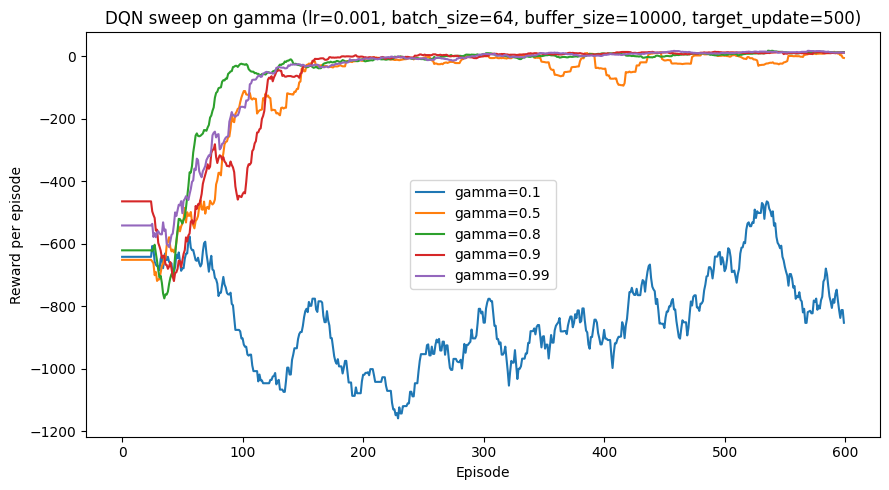

In [ ]:
base_d = {
    "gamma": 0.99,
    "lr": 1e-3,
    "batch_size": 64,
    "buffer_size": 10000,
    "target_update": 500,
    "eps_schedule": EpsilonGreedySchedule(start=1.0, end=0.05, decay_steps=10_000, mode="exp")
}

logs_d = sweep_rewards_dqn(
    env, param="lr", values=[0.005, 0.01, 0.1, 1, 10],
    base=base_d, episodes=600, max_steps=max_steps,
    title="DQN sweep on learning rate",
    out_path="outputs/images/sweep_dqn_lr.png"
)

logs_d = sweep_rewards_dqn(
    env, param="gamma", values=[0.1, 0.5, 0.8, 0.9, 0.99, 0.99],
    base=base_d, episodes=600, max_steps=max_steps,

    title="DQN sweep on gamma",
    out_path="outputs/images/sweep_dqn_gamma.png"
)


## 5) Robustesse: bruit sur l'action (`noise_prob`)

100%|██████████| 1000/1000 [00:04<00:00, 231.57it/s]


Q-learning: training time = 4.64s | evaluation time = 0.00s


100%|██████████| 1000/1000 [00:03<00:00, 284.67it/s]


SARSA: training time = 3.51s | evaluation time = 0.00s


100%|██████████| 1000/1000 [04:46<00:00,  3.49it/s]


DQN: training time = 289.95s | evaluation time = 0.00s


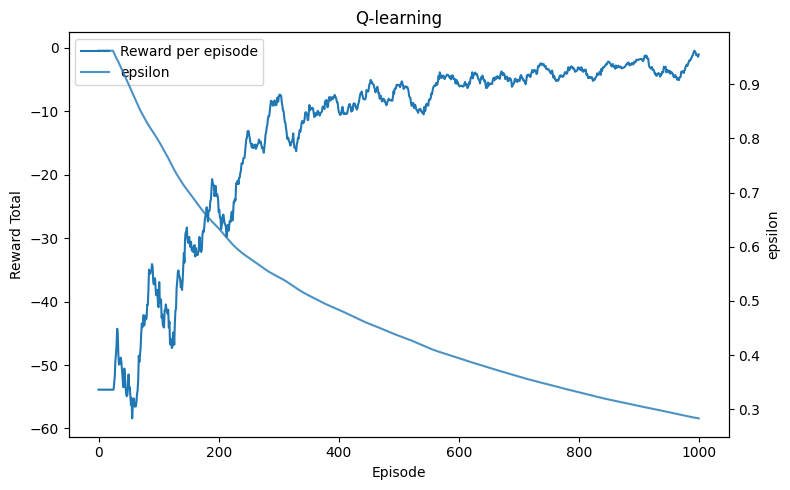

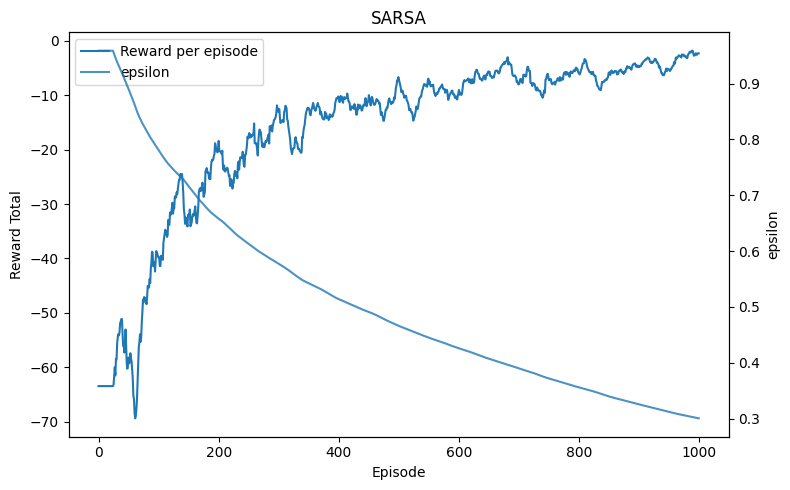

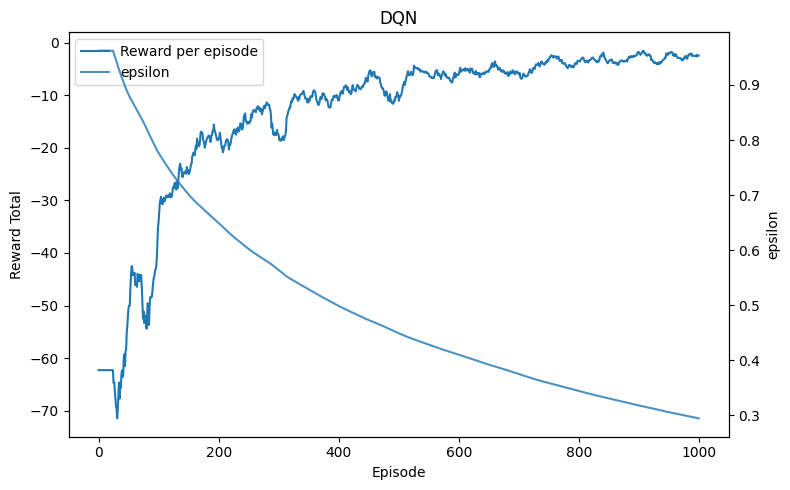


=== Method comparison ===
Q-learning: Winrate: 100.0000% | Mean reward: 2.00
SARSA: Winrate: 100.0000% | Mean reward: 2.00
DQN: Winrate: 100.0000% | Mean reward: 2.00


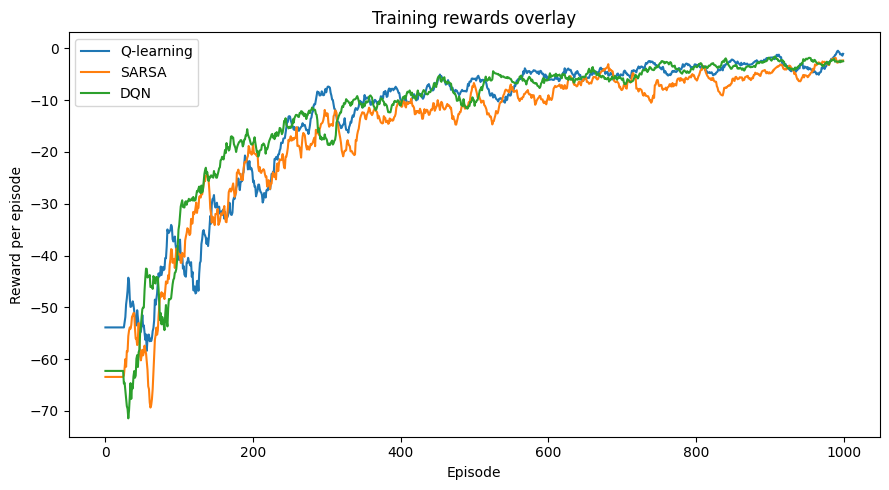

MCTS (noise=0.0): Winrate: 100.0000% | Mean reward: -9.98


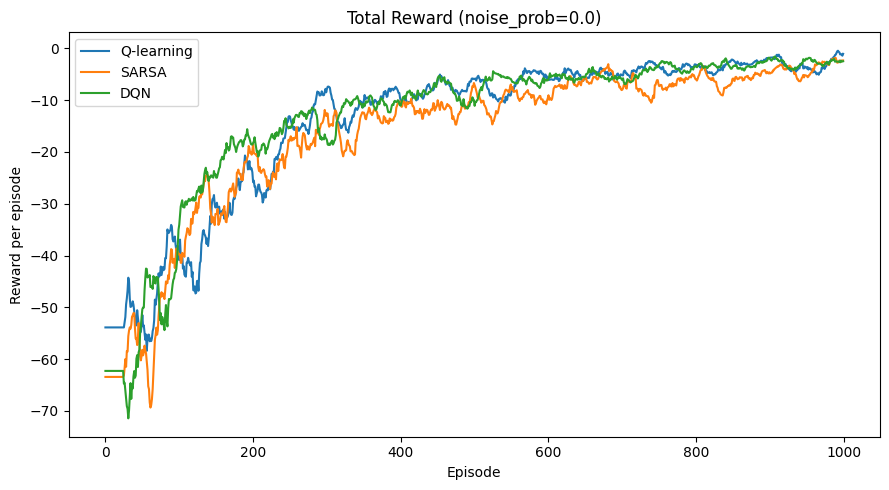

100%|██████████| 1000/1000 [00:04<00:00, 234.17it/s]


Q-learning: training time = 4.29s | evaluation time = 0.00s


100%|██████████| 1000/1000 [00:03<00:00, 275.54it/s]


SARSA: training time = 3.63s | evaluation time = 0.00s


100%|██████████| 1000/1000 [04:55<00:00,  3.39it/s]


DQN: training time = 295.66s | evaluation time = 0.00s


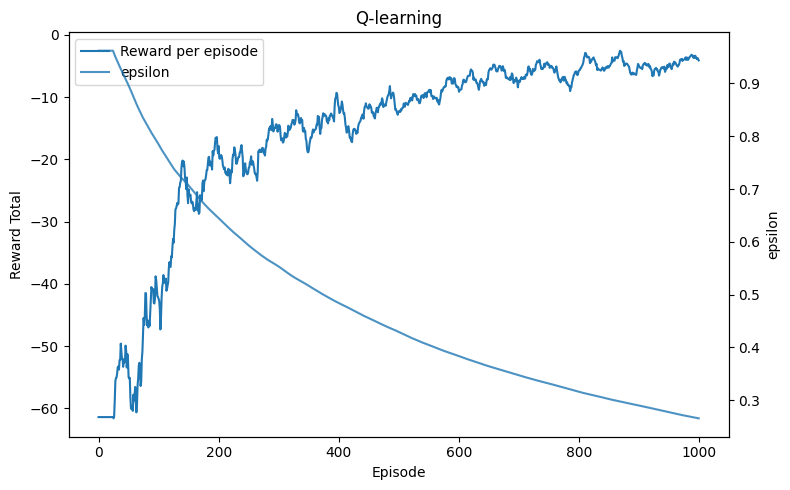

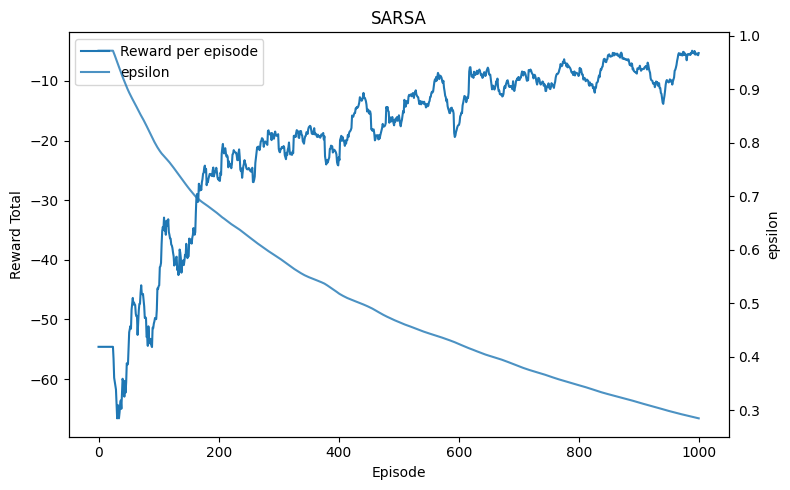

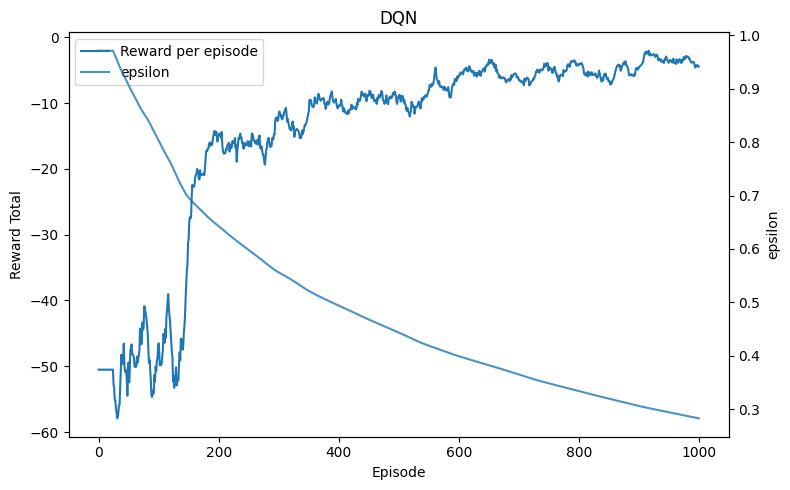


=== Method comparison ===
Q-learning: Winrate: 100.0000% | Mean reward: 0.68
SARSA: Winrate: 100.0000% | Mean reward: 0.19
DQN: Winrate: 100.0000% | Mean reward: 1.08


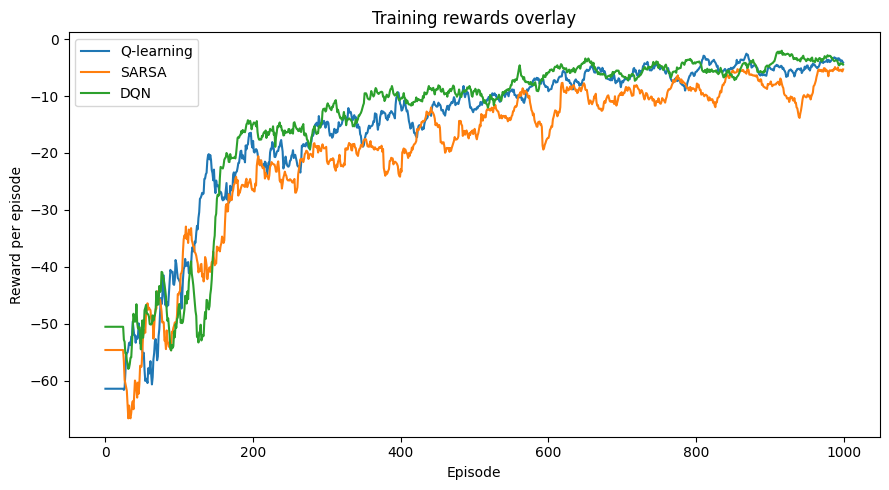

MCTS (noise=0.1): Winrate: 100.0000% | Mean reward: -13.72


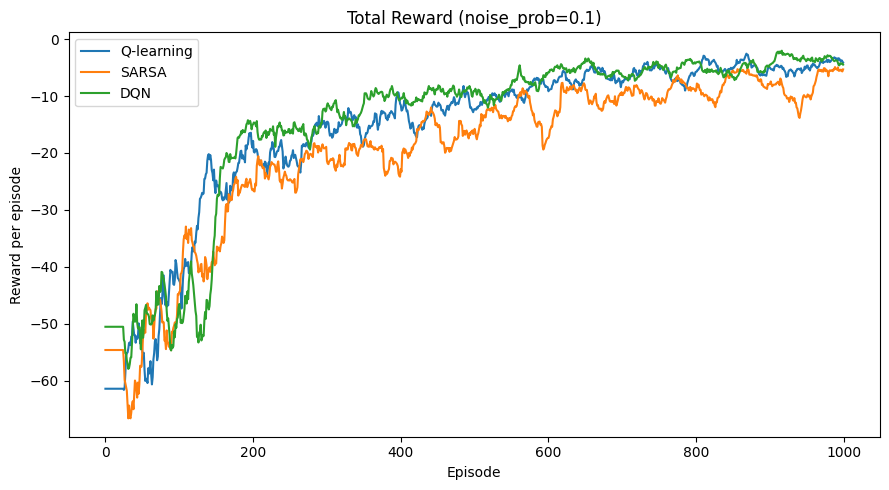

100%|██████████| 1000/1000 [00:04<00:00, 213.81it/s]


Q-learning: training time = 4.68s | evaluation time = 0.00s


100%|██████████| 1000/1000 [00:03<00:00, 252.09it/s]


SARSA: training time = 3.97s | evaluation time = 0.00s


100%|██████████| 1000/1000 [05:15<00:00,  3.17it/s]


DQN: training time = 315.84s | evaluation time = 0.00s


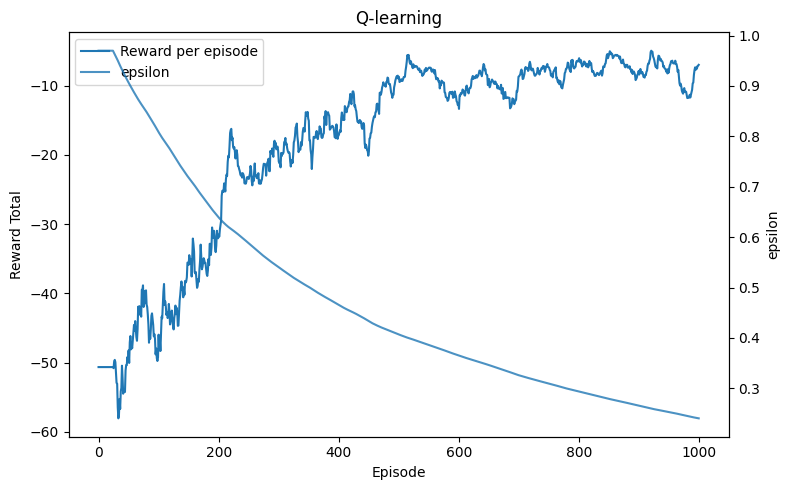

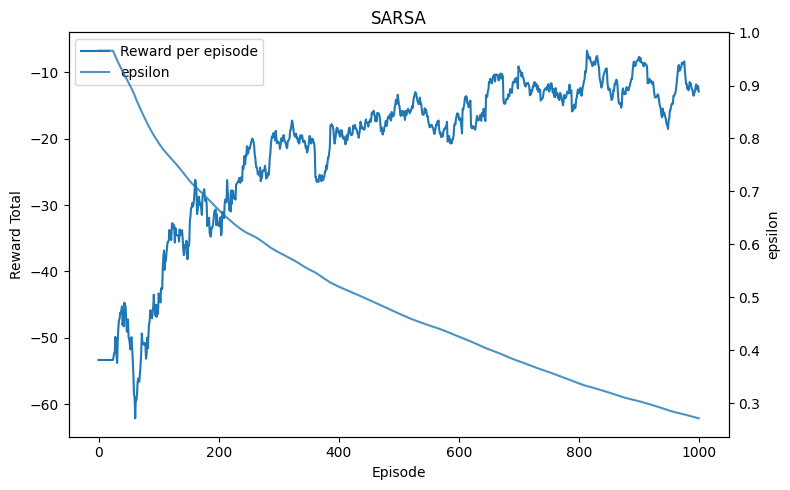

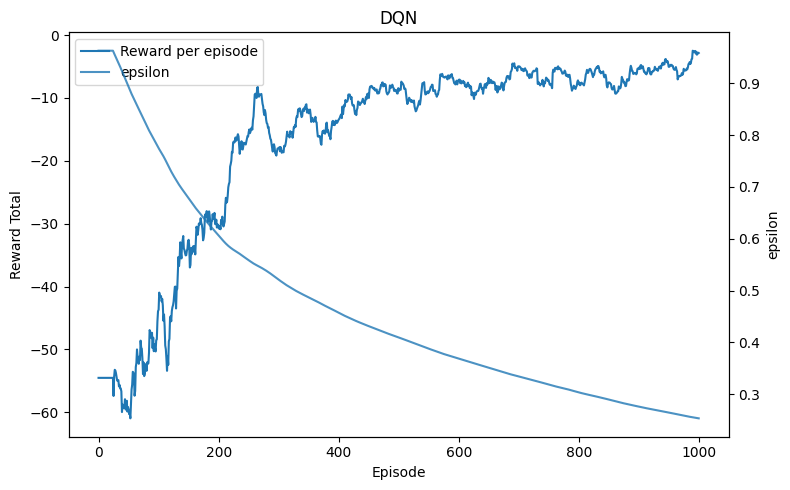


=== Method comparison ===
Q-learning: Winrate: 100.0000% | Mean reward: -1.06
SARSA: Winrate: 93.0000% | Mean reward: -1.61
DQN: Winrate: 100.0000% | Mean reward: -0.11


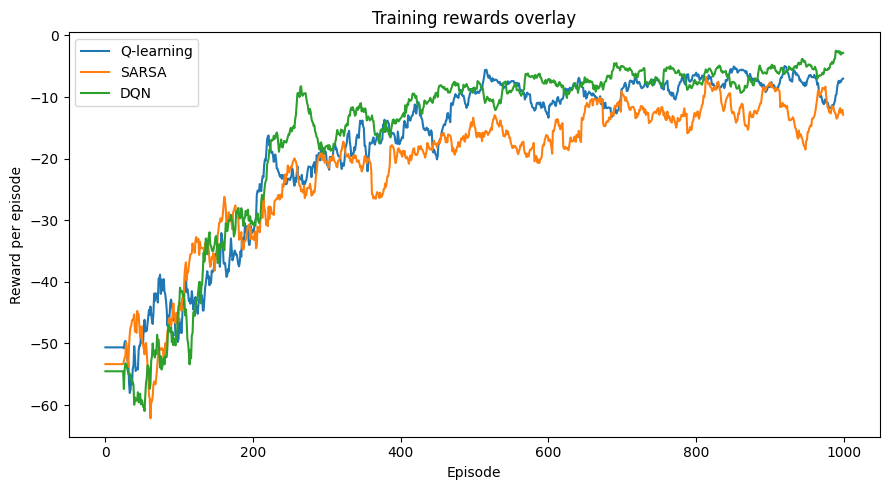

MCTS (noise=0.2): Winrate: 100.0000% | Mean reward: -16.84


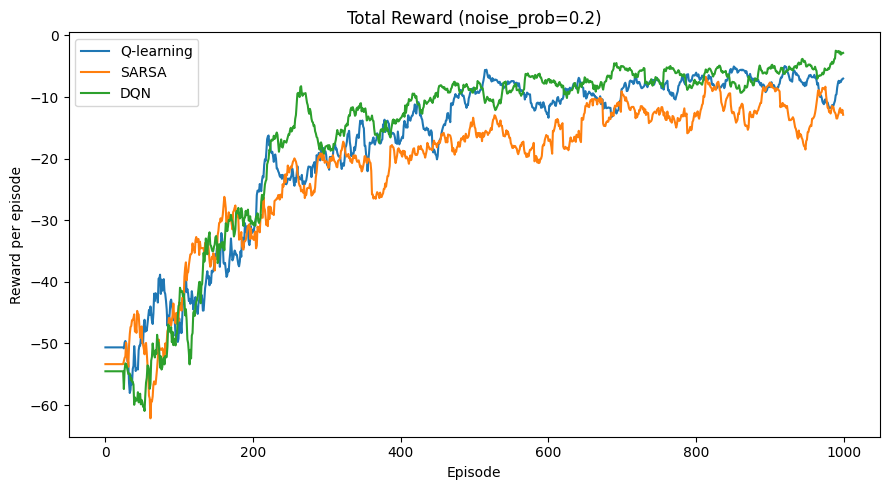

100%|██████████| 1000/1000 [00:06<00:00, 160.35it/s]


Q-learning: training time = 6.24s | evaluation time = 0.00s


100%|██████████| 1000/1000 [00:04<00:00, 223.79it/s]


SARSA: training time = 4.47s | evaluation time = 0.00s


100%|██████████| 1000/1000 [06:42<00:00,  2.49it/s]


DQN: training time = 402.32s | evaluation time = 0.01s


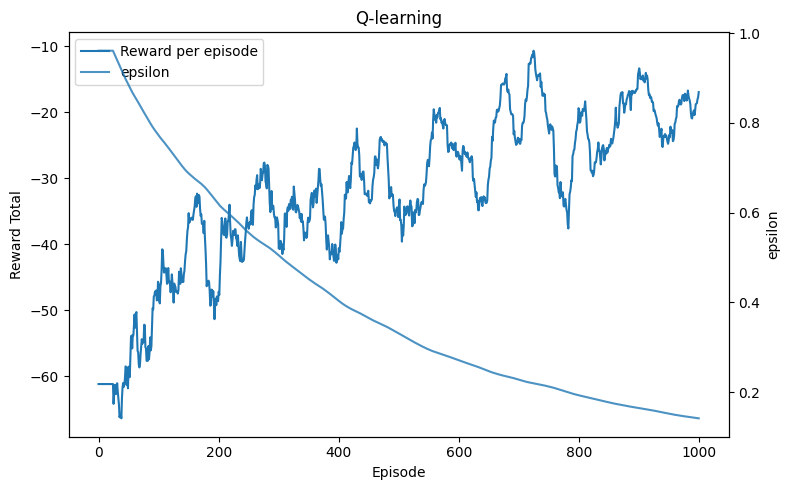

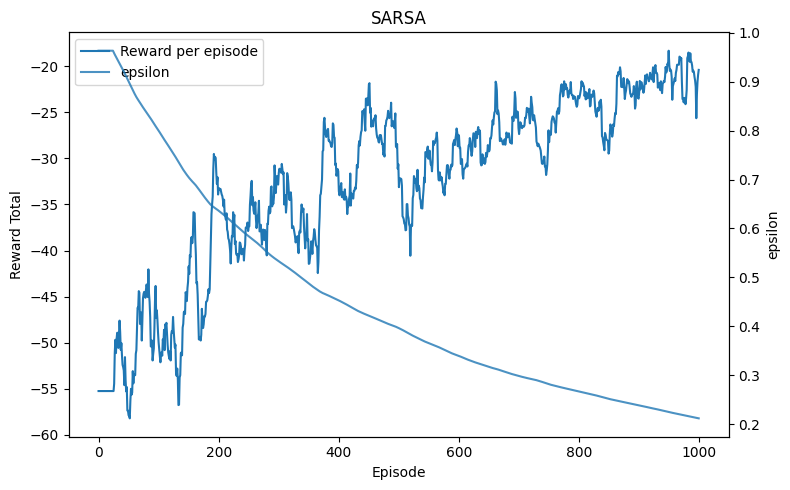

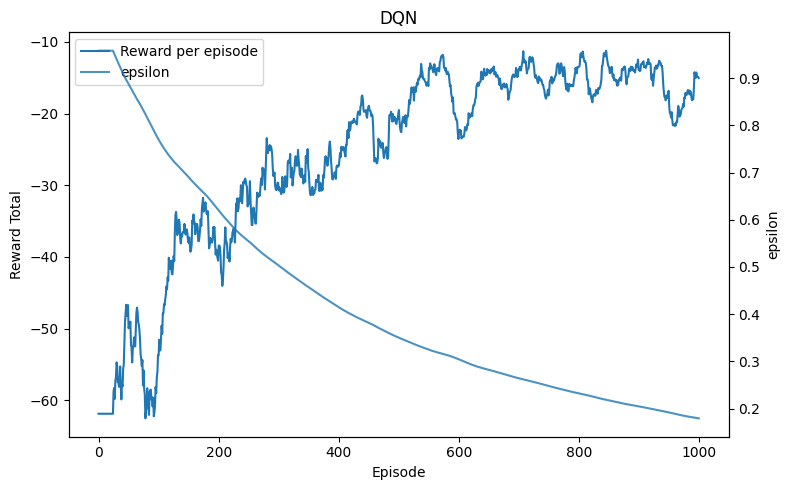


=== Method comparison ===
Q-learning: Winrate: 79.0000% | Mean reward: -15.11
SARSA: Winrate: 69.0000% | Mean reward: -12.02
DQN: Winrate: 89.0000% | Mean reward: -8.86


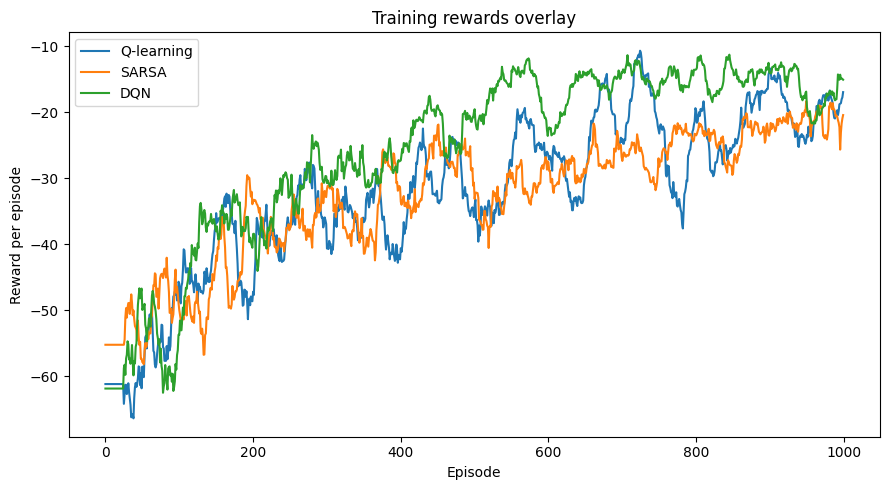

MCTS (noise=0.5): Winrate: 96.0000% | Mean reward: -30.70


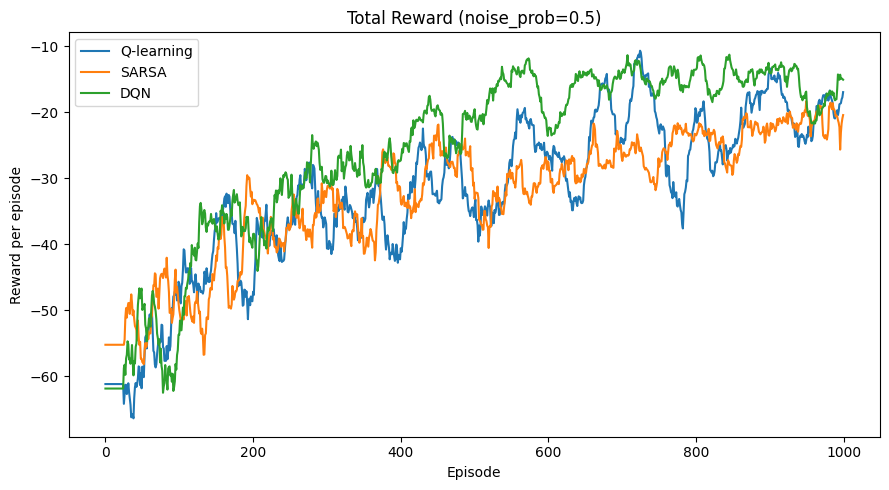

100%|██████████| 1000/1000 [00:09<00:00, 107.57it/s]


Q-learning: training time = 9.30s | evaluation time = 0.00s


100%|██████████| 1000/1000 [00:09<00:00, 109.33it/s]


SARSA: training time = 9.15s | evaluation time = 0.00s


100%|██████████| 1000/1000 [12:46<00:00,  1.30it/s]


DQN: training time = 767.06s | evaluation time = 0.03s


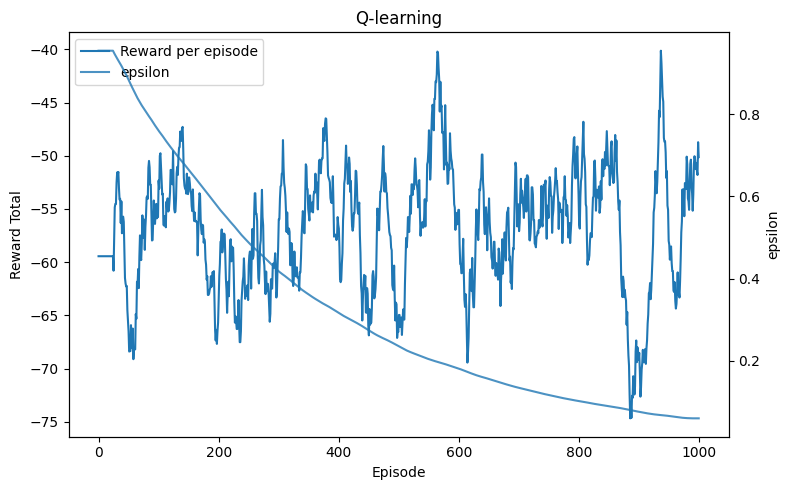

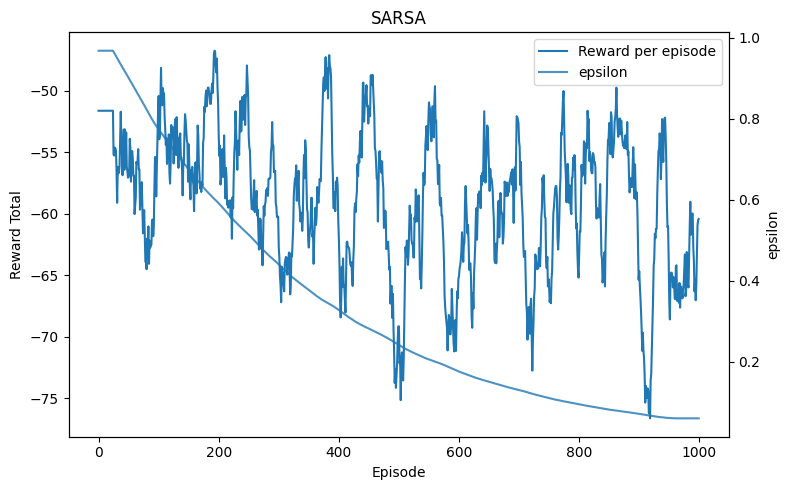

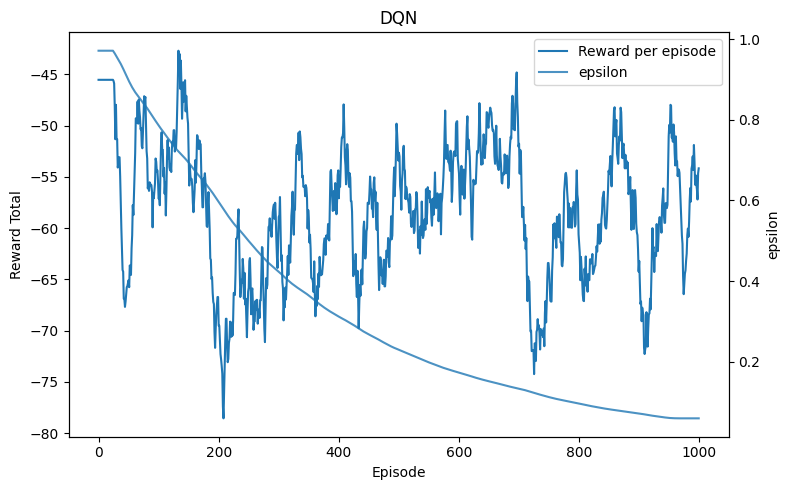


=== Method comparison ===
Q-learning: Winrate: 8.0000% | Mean reward: -54.41
SARSA: Winrate: 5.0000% | Mean reward: -60.95
DQN: Winrate: 10.0000% | Mean reward: -55.41


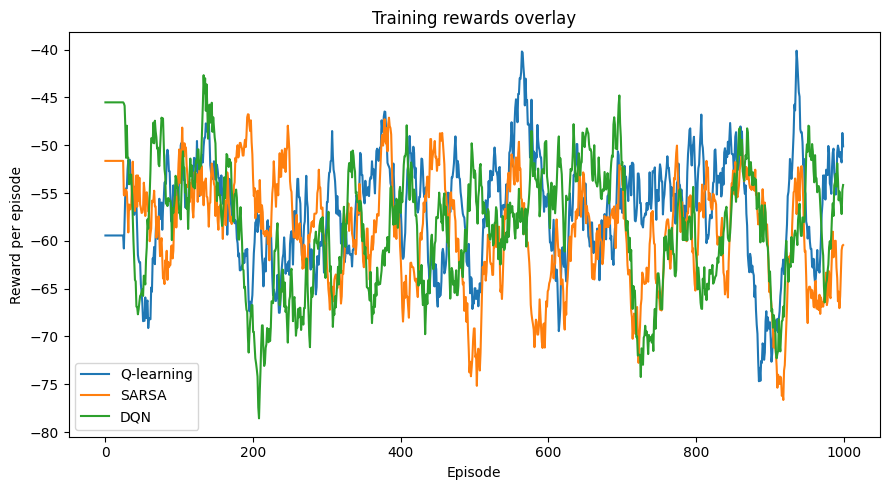

MCTS (noise=1): Winrate: 4.0000% | Mean reward: -128.36


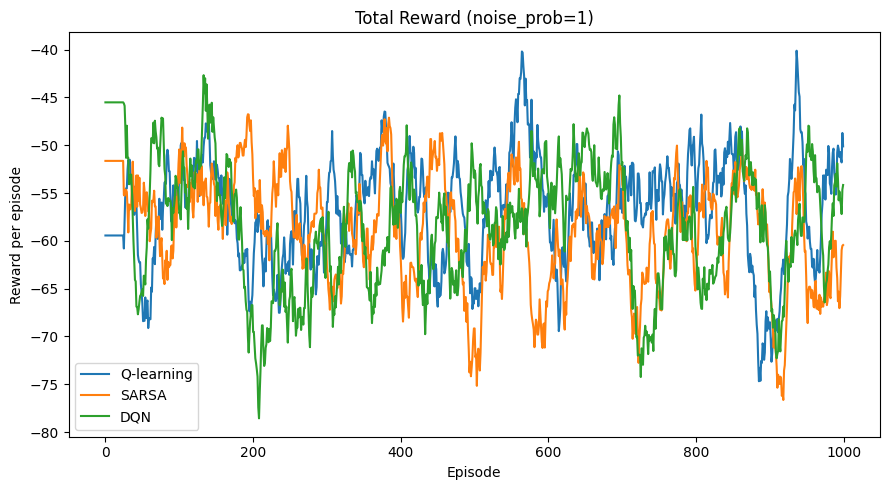

{0.0: {'Q-learning': {'win_rate': 1.0, 'mean_reward': 2.0},
  'SARSA': {'win_rate': 1.0, 'mean_reward': 2.0},
  'DQN': {'win_rate': 1.0, 'mean_reward': 2.0},
  'MCTS': {'win_rate': 1.0, 'mean_reward': -9.98}},
 0.1: {'Q-learning': {'win_rate': 1.0, 'mean_reward': 0.68},
  'SARSA': {'win_rate': 1.0, 'mean_reward': 0.19},
  'DQN': {'win_rate': 1.0, 'mean_reward': 1.08},
  'MCTS': {'win_rate': 1.0, 'mean_reward': -13.72}},
 0.2: {'Q-learning': {'win_rate': 1.0, 'mean_reward': -1.06},
  'SARSA': {'win_rate': 0.93, 'mean_reward': -1.61},
  'DQN': {'win_rate': 1.0, 'mean_reward': -0.11},
  'MCTS': {'win_rate': 1.0, 'mean_reward': -16.84}},
 0.5: {'Q-learning': {'win_rate': 0.79, 'mean_reward': -15.11},
  'SARSA': {'win_rate': 0.69, 'mean_reward': -12.02},
  'DQN': {'win_rate': 0.89, 'mean_reward': -8.86},
  'MCTS': {'win_rate': 0.96, 'mean_reward': -30.7}},
 1: {'Q-learning': {'win_rate': 0.08, 'mean_reward': -54.41},
  'SARSA': {'win_rate': 0.05, 'mean_reward': -60.95},
  'DQN': {'win_rate'

In [ ]:
robust_noise_levels = [0.0, 0.1, 0.2, 0.5, 1]
robust_metrics = {}

for p in robust_noise_levels:
    env_rob = PacmanGridEnv(grid=grid, dot_pos=dot_pos, ghost_starts=ghost_starts, pacman_start=pacman_start,
        noise_prob=p, random_start=False, move_prob_ghost=0.0, n_ghosts=2, seed=0, assets_dir='assets'
    )

    res = train_all(env_rob, out_dir=out_dir, episodes=1000, max_steps=max_steps, gamma=0.99, eps_mode='exp')

    env_rob.ghost_penalty = -100
    env_rob.dot_reward = 10
    env_rob.step_cost = -1

    def mcts_policy(_obs): 
        return plan_action(env_rob, simulations=500, c=1, rollout_depth=20, gamma=0.99)
    
    robust_mcts_metrics = eval_policy(env_rob, mcts_policy, episodes=50, max_steps=max_steps)

    wr = robust_mcts_metrics['win_rate'] * 100
    mr = robust_mcts_metrics['mean_reward']
    print(f"MCTS (noise={p}): Winrate: {wr:.4f}% | Mean reward: {mr:.2f}")

    logs = {k: v[1] for k, v in res.items()}
    plot_overlay_rewards(
        logs,
        title=f'Total Reward (noise_prob={p})',
        out_path=f"{out_dir}/overlay_noise_{p}.png"
    )

    metrics_dict = {k: v[2] for k, v in res.items()} 
    metrics_dict["MCTS"] = robust_mcts_metrics       

    robust_metrics[p] = metrics_dict

robust_metrics


## 6) Dynamisme: départs aléatoires + fantômes mobiles

100%|██████████| 1000/1000 [00:03<00:00, 308.13it/s]


Q-learning: training time = 3.25s | evaluation time = 0.00s


100%|██████████| 1000/1000 [00:02<00:00, 367.35it/s]


SARSA: training time = 2.73s | evaluation time = 0.00s


100%|██████████| 1000/1000 [03:35<00:00,  4.64it/s]


DQN: training time = 215.88s | evaluation time = 0.00s


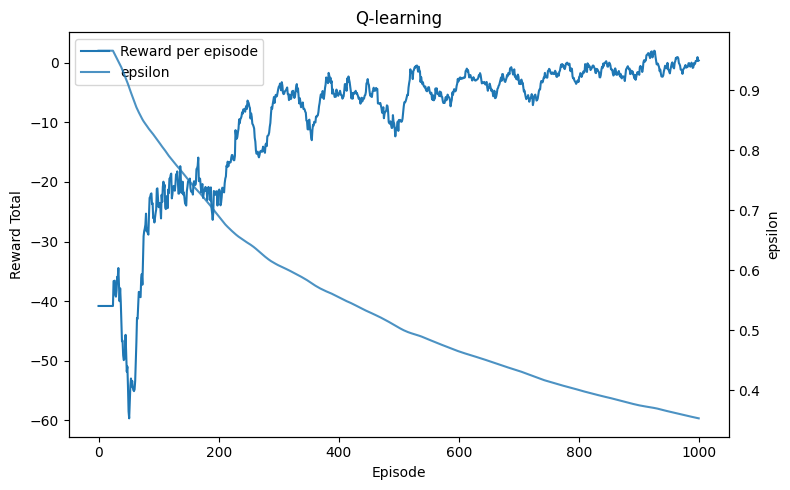

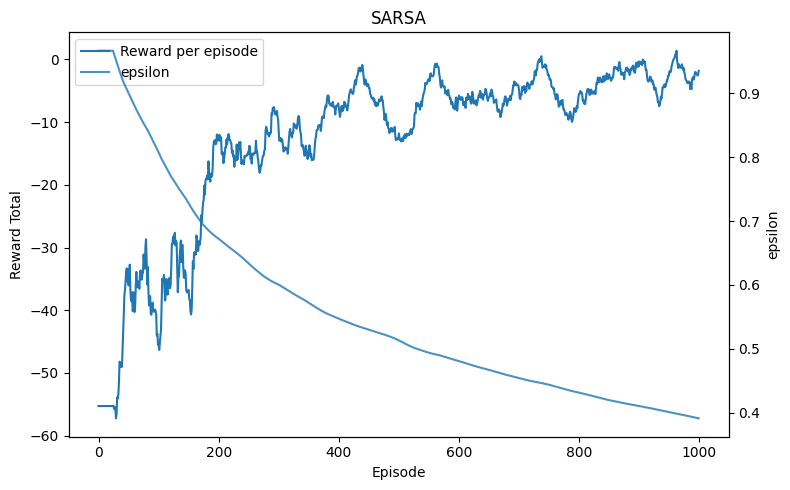

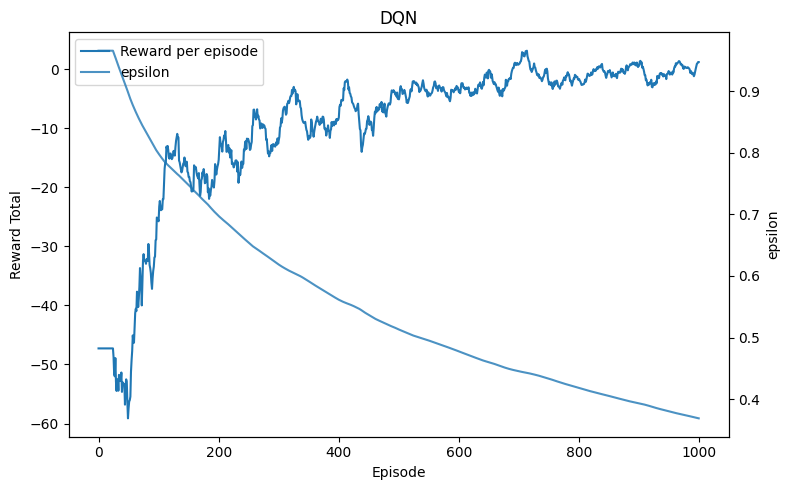


=== Method comparison ===
Q-learning: Winrate: 100.0000% | Mean reward: 3.96
SARSA: Winrate: 75.0000% | Mean reward: -2.68
DQN: Winrate: 100.0000% | Mean reward: 3.63


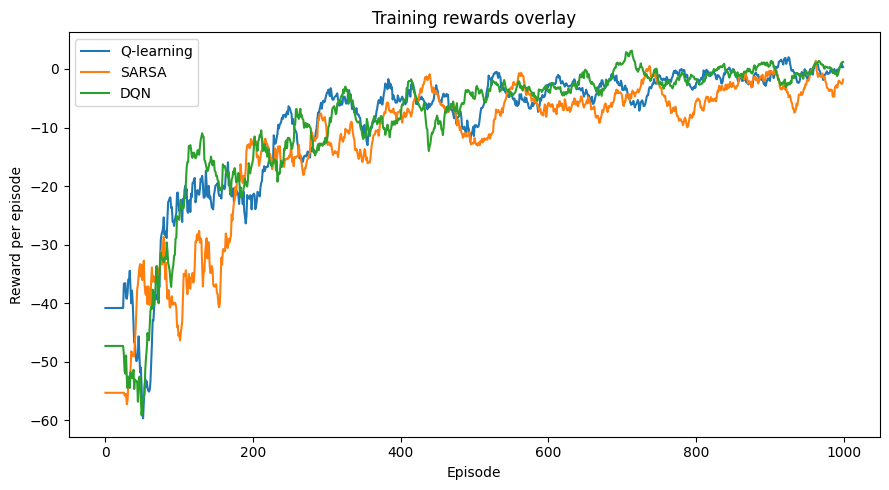

MCTS (move_prob_ghost=0.0): Winrate: 100.0000% | Mean reward: -1.84


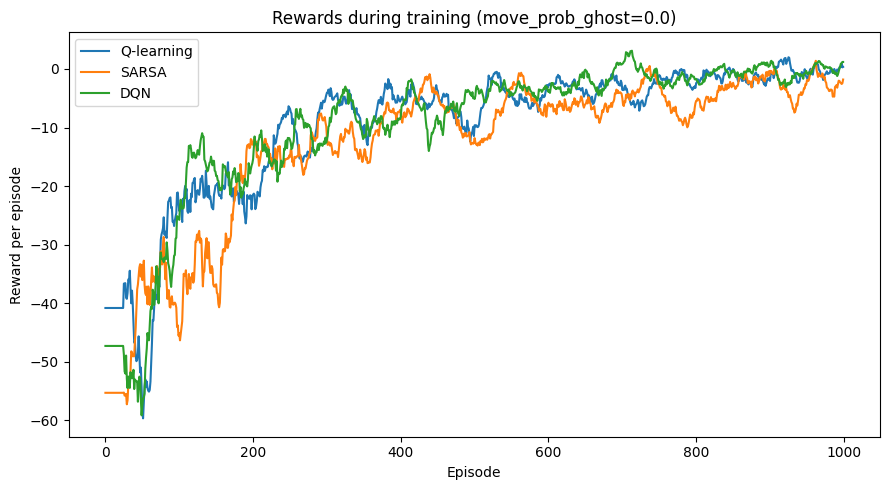

100%|██████████| 1000/1000 [00:10<00:00, 97.37it/s]


Q-learning: training time = 10.27s | evaluation time = 0.00s


100%|██████████| 1000/1000 [00:09<00:00, 103.33it/s]


SARSA: training time = 9.68s | evaluation time = 0.00s


100%|██████████| 1000/1000 [03:56<00:00,  4.23it/s]


DQN: training time = 236.58s | evaluation time = 0.00s


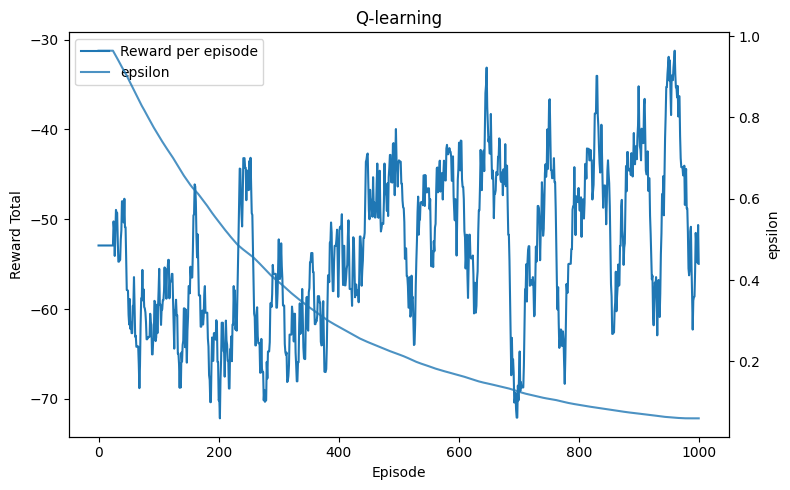

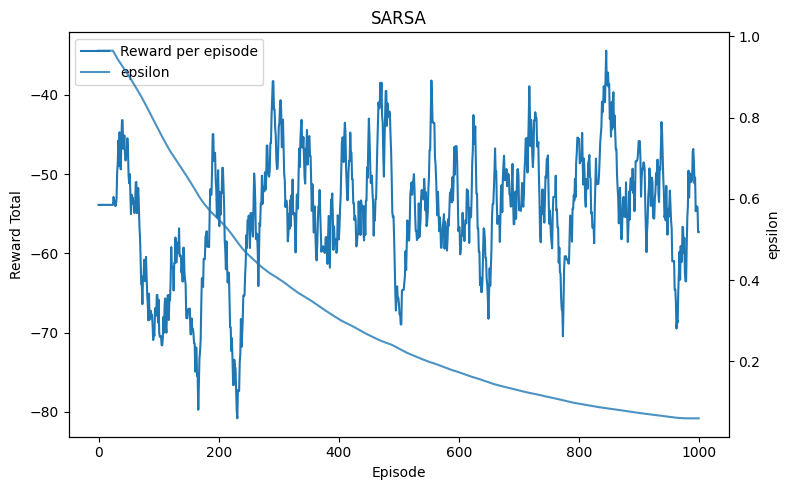

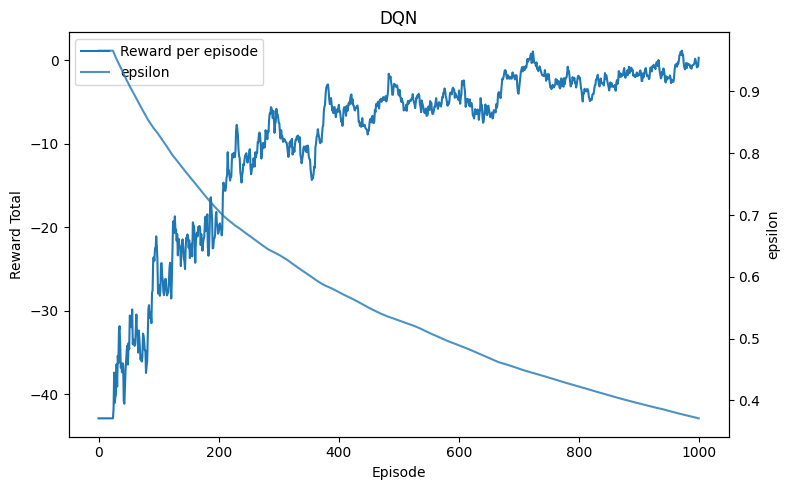


=== Method comparison ===
Q-learning: Winrate: 25.0000% | Mean reward: -55.01
SARSA: Winrate: 29.0000% | Mean reward: -49.49
DQN: Winrate: 100.0000% | Mean reward: 4.04


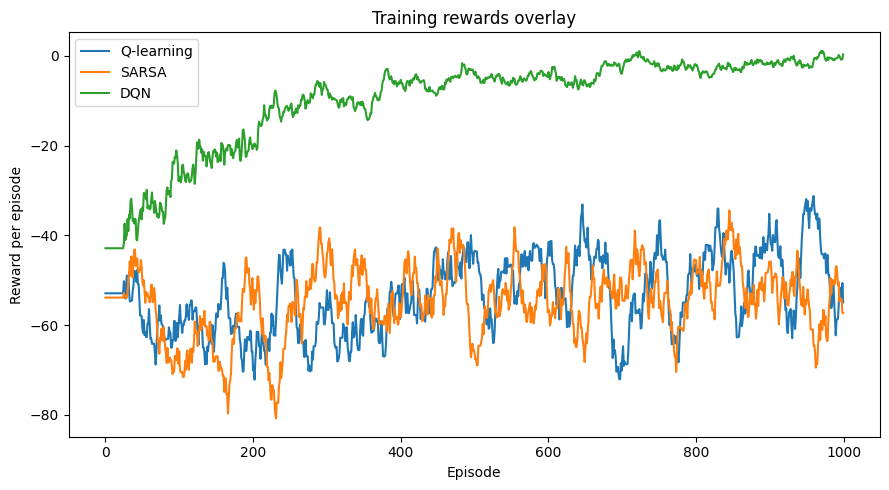

MCTS (move_prob_ghost=0.2): Winrate: 86.0000% | Mean reward: -17.42


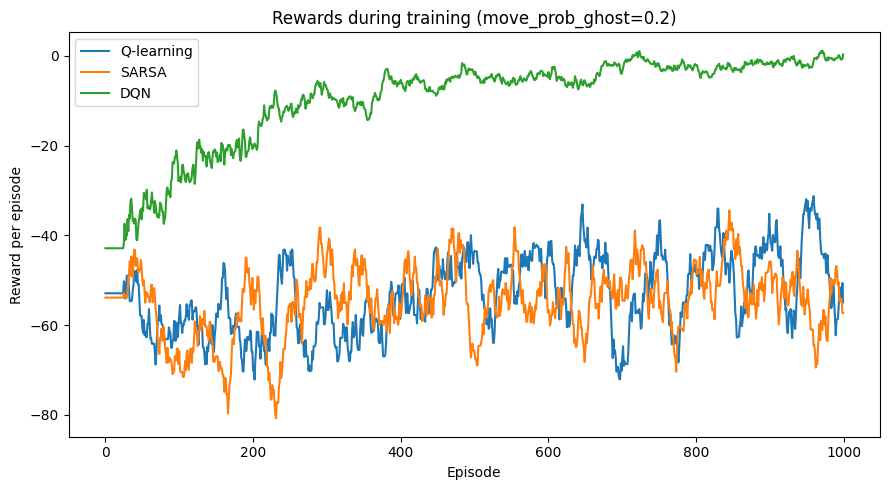

100%|██████████| 1000/1000 [00:11<00:00, 89.83it/s]


Q-learning: training time = 11.13s | evaluation time = 0.00s


100%|██████████| 1000/1000 [00:11<00:00, 88.62it/s]


SARSA: training time = 11.29s | evaluation time = 0.00s


100%|██████████| 1000/1000 [03:54<00:00,  4.27it/s]


DQN: training time = 234.06s | evaluation time = 0.00s


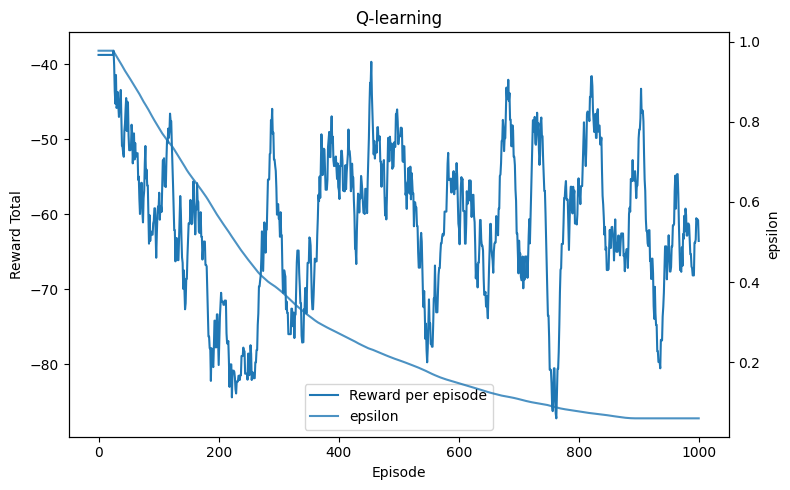

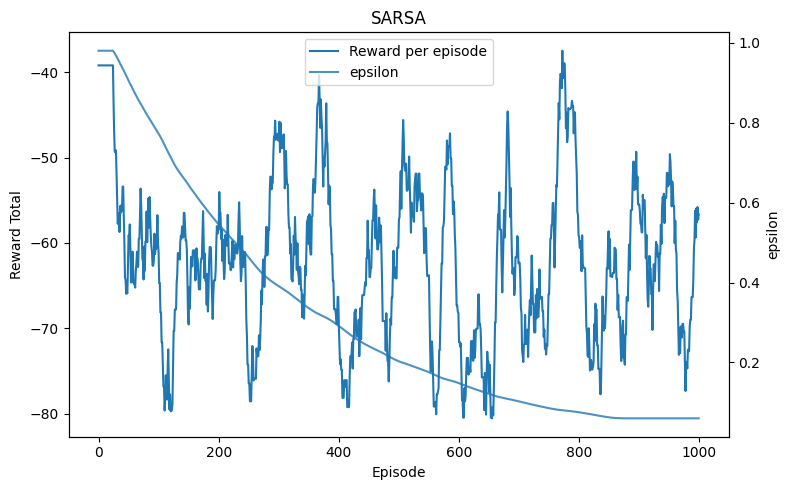

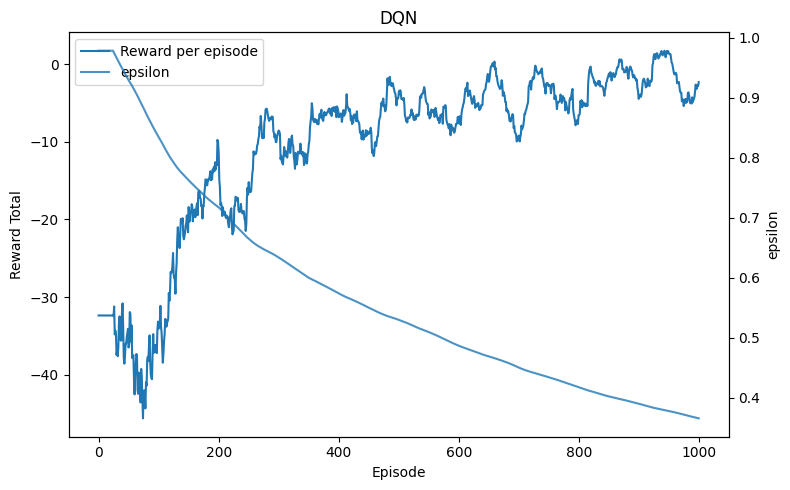


=== Method comparison ===
Q-learning: Winrate: 16.0000% | Mean reward: -64.69
SARSA: Winrate: 12.0000% | Mean reward: -62.72
DQN: Winrate: 98.0000% | Mean reward: 3.63


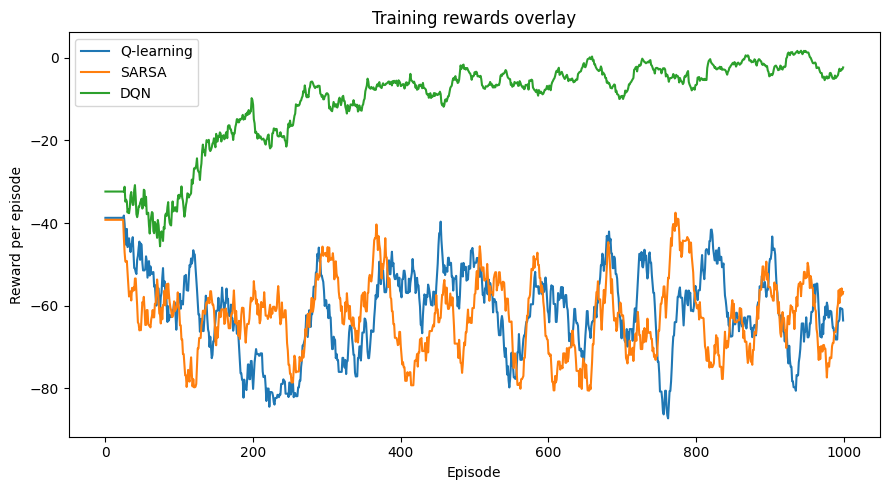

MCTS (move_prob_ghost=0.5): Winrate: 86.0000% | Mean reward: -22.20


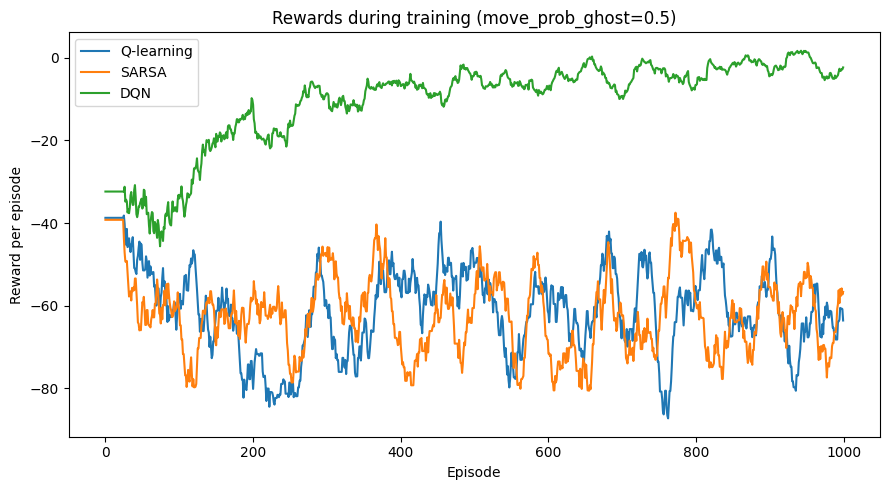

100%|██████████| 1000/1000 [00:11<00:00, 86.58it/s]


Q-learning: training time = 11.55s | evaluation time = 0.00s


100%|██████████| 1000/1000 [00:11<00:00, 89.98it/s]


SARSA: training time = 11.11s | evaluation time = 0.00s


100%|██████████| 1000/1000 [03:59<00:00,  4.17it/s]


DQN: training time = 239.68s | evaluation time = 0.00s


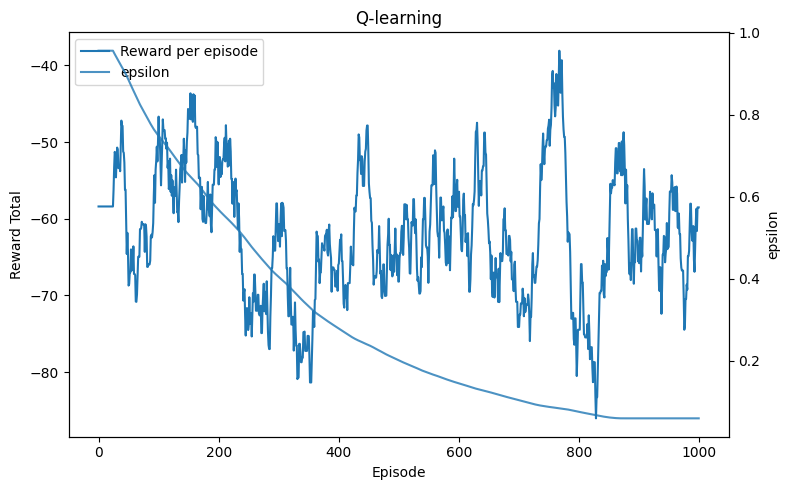

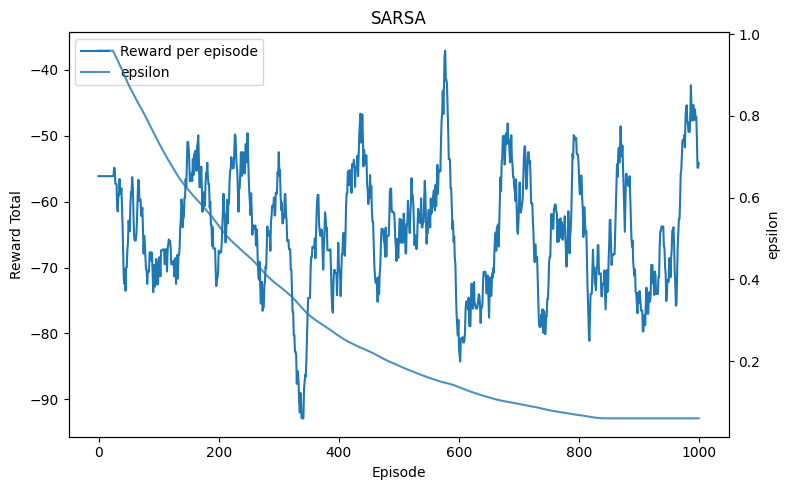

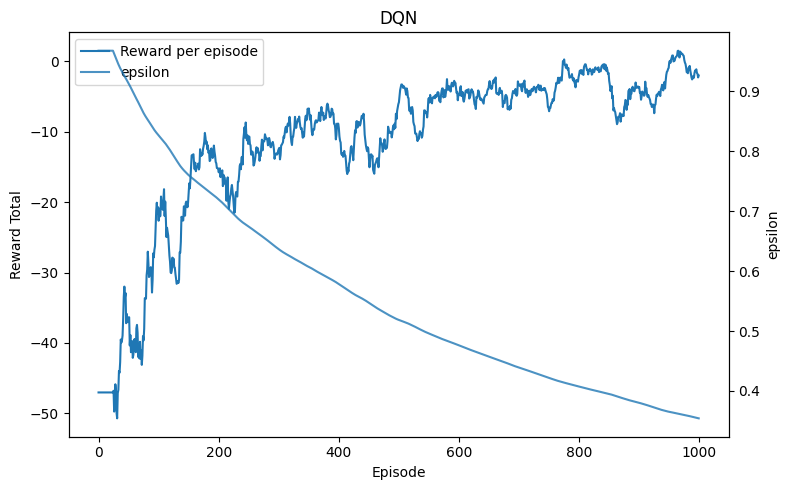


=== Method comparison ===
Q-learning: Winrate: 4.0000% | Mean reward: -65.85
SARSA: Winrate: 10.0000% | Mean reward: -62.00
DQN: Winrate: 97.0000% | Mean reward: 3.57


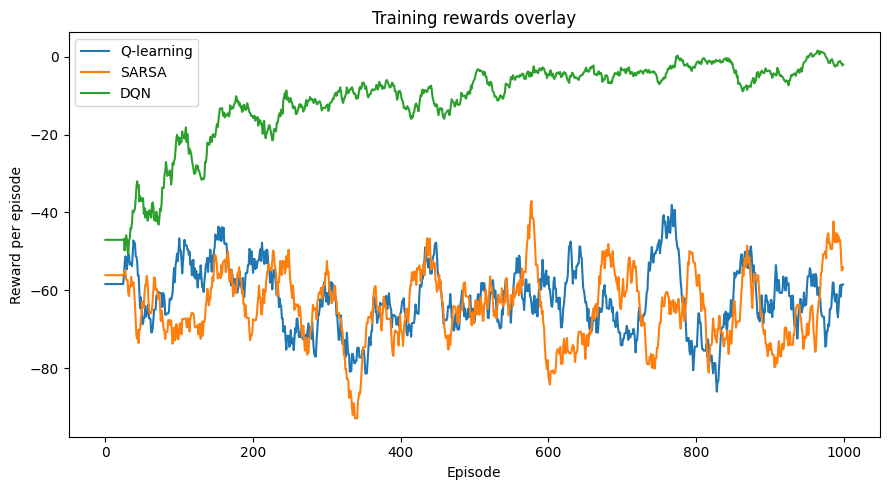

MCTS (move_prob_ghost=1): Winrate: 76.0000% | Mean reward: -31.34


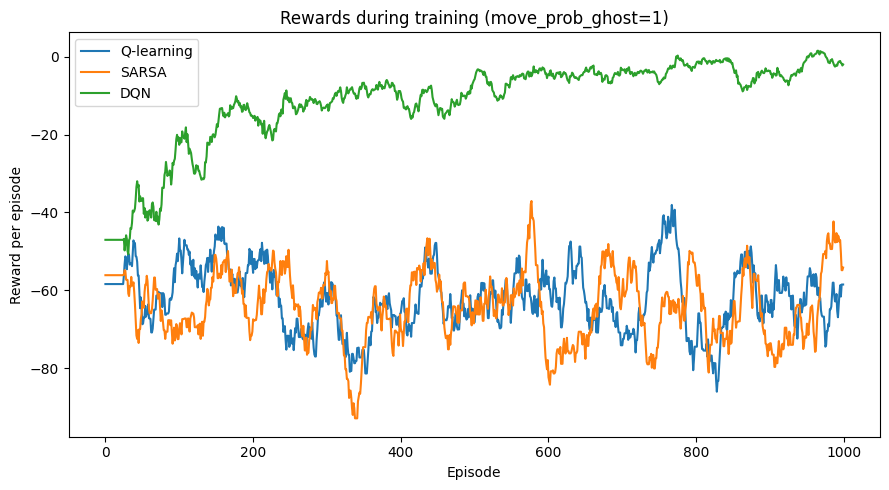

{0.0: {'Q-learning': {'win_rate': 1.0, 'mean_reward': 3.96},
  'SARSA': {'win_rate': 0.75, 'mean_reward': -2.68},
  'DQN': {'win_rate': 1.0, 'mean_reward': 3.63},
  'MCTS': {'win_rate': 1.0, 'mean_reward': -1.84}},
 0.2: {'Q-learning': {'win_rate': 0.25, 'mean_reward': -55.01},
  'SARSA': {'win_rate': 0.29, 'mean_reward': -49.49},
  'DQN': {'win_rate': 1.0, 'mean_reward': 4.04},
  'MCTS': {'win_rate': 0.86, 'mean_reward': -17.42}},
 0.5: {'Q-learning': {'win_rate': 0.16, 'mean_reward': -64.69},
  'SARSA': {'win_rate': 0.12, 'mean_reward': -62.72},
  'DQN': {'win_rate': 0.98, 'mean_reward': 3.63},
  'MCTS': {'win_rate': 0.86, 'mean_reward': -22.2}},
 1: {'Q-learning': {'win_rate': 0.04, 'mean_reward': -65.85},
  'SARSA': {'win_rate': 0.1, 'mean_reward': -62.0},
  'DQN': {'win_rate': 0.97, 'mean_reward': 3.57},
  'MCTS': {'win_rate': 0.76, 'mean_reward': -31.34}}}

In [ ]:
dyn_move_probs = [0.0, 0.2, 0.5, 1]
dyn_metrics = {}

for mp in dyn_move_probs:
    env_dyn = PacmanGridEnv(grid=grid, dot_pos=dot_pos, ghost_starts=ghost_starts, pacman_start=pacman_start,
        noise_prob=0.0, random_start=True, move_prob_ghost=mp, n_ghosts=2,
        seed=0, assets_dir='assets'

    )
    res = train_all(env_dyn, out_dir=out_dir, episodes=1000, max_steps=max_steps, gamma=0.99, eps_mode='exp')

    env_dyn.ghost_penalty = -100
    env_dyn.dot_reward = 10
    env_dyn.step_cost = -1

    def mcts_policy(_obs):
        return plan_action(env_dyn, simulations=200, c=1, rollout_depth=20, gamma=0.99)

    dyn_mcts_metrics = eval_policy(env_dyn, mcts_policy, episodes=50, max_steps=max_steps)

    wr = dyn_mcts_metrics['win_rate'] * 100
    mr = dyn_mcts_metrics['mean_reward']
    print(f"MCTS (move_prob_ghost={mp}): Winrate: {wr:.4f}% | Mean reward: {mr:.2f}")

    logs = {k: v[1] for k, v in res.items() if v[1] is not None}
    plot_overlay_rewards(
        logs,
        title=f'Rewards during training (move_prob_ghost={mp})',
        out_path=f"{out_dir}/overlay_dyn_{mp}.png"
    )
    metrics_dict = {k: v[2] for k, v in res.items()}
    metrics_dict["MCTS"] = dyn_mcts_metrics  

    dyn_metrics[mp] = metrics_dict


dyn_metrics